--- Hierarchical Dataset Audit ---
Total Observations: 1000
Features Detected:  ['property_type', 'n_rooms', 'dist_centre_km', 'outdoor_space', 'near_underground', 'intercept', 'beta_room', 'beta_dist', 'beta_under', 'beta_prop', 'beta_outdoor', 'premium', 'monthly_rent_gbp', 'listing_type']
------------------------------
Injected Agent Premium Mean:  0.1500
Injected Agent Premium Sigma: 0.0280


,property_type,n_rooms,dist_centre_km,outdoor_space,near_underground,intercept,beta_room,beta_dist,beta_under,beta_prop,beta_outdoor,premium,monthly_rent_gbp,listing_type
0,Flat,6,3.390471,Garden,0,7.524821,0.186030,-0.012522,0.00000,0.000000,0.165505,0.0,6187.654213,Owner
1,House,2,0.340417,Garden,0,7.501267,0.136840,-0.030720,0.00000,0.175935,0.133538,0.0,3234.967009,Owner
2,House,2,12.910090,Garden,0,7.502784,0.135677,-0.045761,0.00000,0.217322,0.141955,0.0,2027.035281,Owner
3,Flat,2,24.534868,Nothing,0,7.498843,0.180849,-0.051848,0.00000,0.000000,0.000000,0.0,729.899977,Owner
4,Flat,3,1.454561,Nothing,1,7.467931,0.147550,-0.031686,0.09676,0.000000,0.000000,0.0,2830.156385,Owner


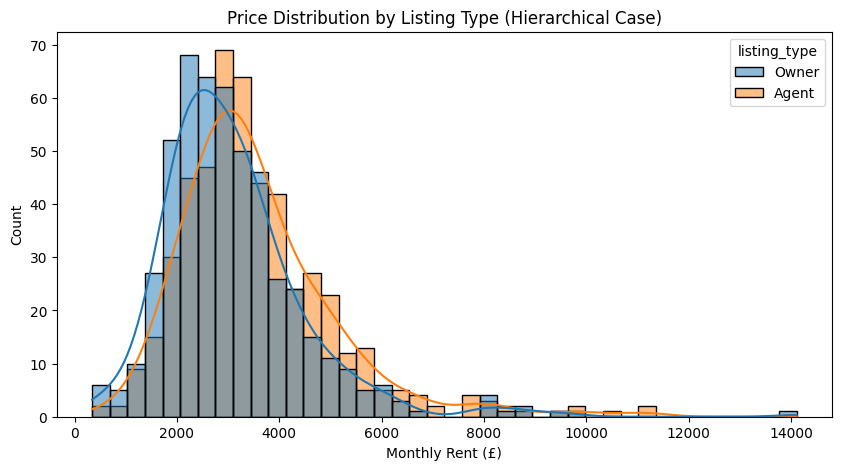

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import json
from scipy.stats import gamma

# --- LOAD HIERARCHICAL DATA ---
file_path = "../../data/datasets/london_rentals_hierarchical.json"

with open(file_path, 'r') as f:
    payload = json.load(f)

# Extract the "Answer Key" for the Market
owner_market = payload['metadata']['owner_market_truth']
agent_market = payload['metadata']['agent_market_truth']

# Extract the "Observations" for the EDA
df = pd.DataFrame(payload['properties'])

# --- INITIAL DATA AUDIT ---
print(f"--- Hierarchical Dataset Audit ---")
print(f"Total Observations: {len(df)}")
print(f"Features Detected:  {list(df.columns)}")
print("-" * 30)

# Quick check on the Agent Premium in the ground truth
print(f"Injected Agent Premium Mean:  {agent_market['means']['premium']:.4f}")
print(f"Injected Agent Premium Sigma: {agent_market['sigmas']['premium']:.4f}")

# Display first few rows to see individual property betas
display(df.head())

# --- BASIC PRICE DISTRIBUTION ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='monthly_rent_gbp', hue='listing_type', kde=True, bins=40)
plt.title("Price Distribution by Listing Type (Hierarchical Case)")
plt.xlabel("Monthly Rent (£)")
plt.show()

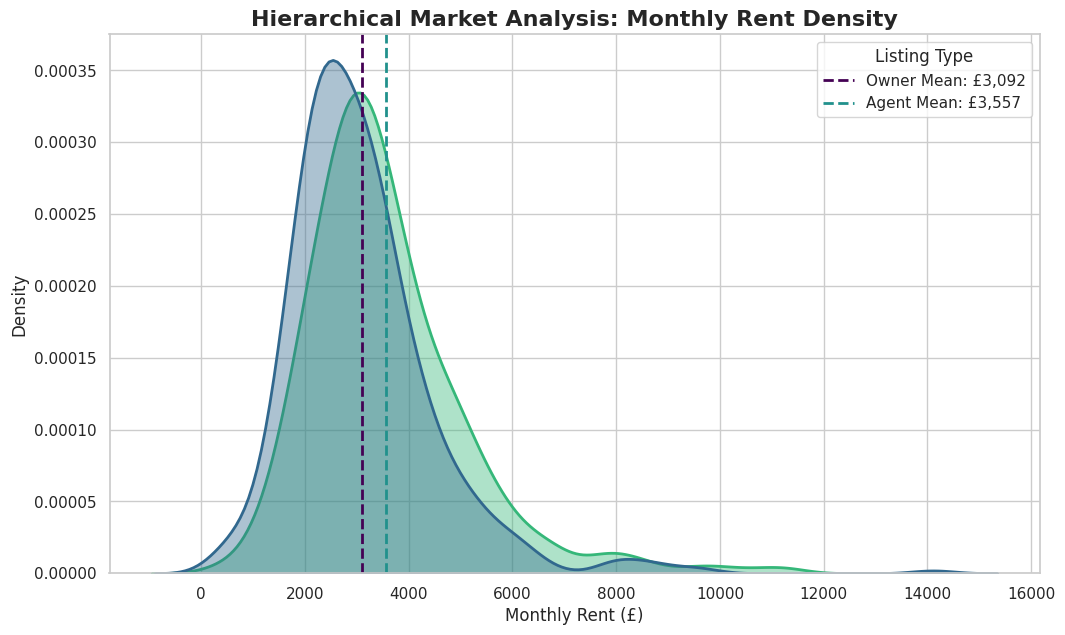

--- Hierarchical Price Summary ---
                  mean    median       std  count  coeff_variation  markup_pct
listing_type                                                                  
Agent         3556.769  3279.569  1544.385    500            0.434      15.044
Owner         3091.667  2848.787  1425.965    500            0.461       0.000


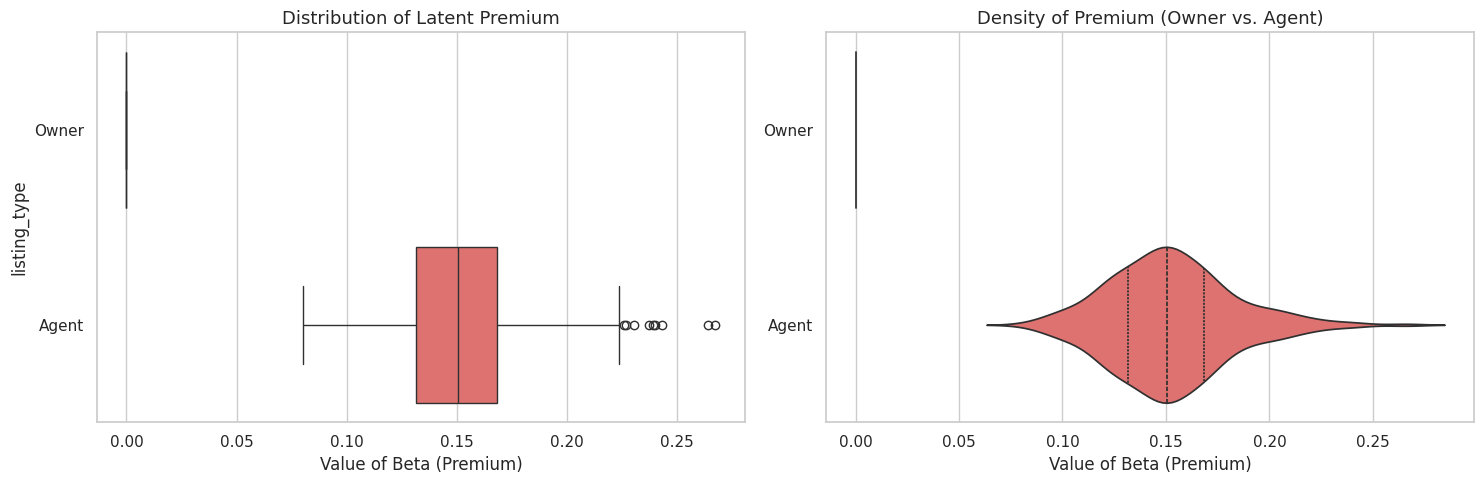

--- Owner Premium Audit ---
Mean: 0.0000 | Max: 0.0000
Status: Verified clean. No 'Premium' noise in Owner group.


In [2]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Plot the distribution of prices
ax = sns.kdeplot(
    data=df, x='monthly_rent_gbp', hue='listing_type', 
    fill=True, common_norm=False, palette='viridis', alpha=0.4, linewidth=2
)

# Calculate means for the lines
owner_mean = df[df['listing_type']=='Owner']['monthly_rent_gbp'].mean()
agent_mean = df[df['listing_type']=='Agent']['monthly_rent_gbp'].mean()

# Add vertical lines with labels for the means
plt.axvline(owner_mean, color='#440154', linestyle='--', linewidth=2, label=f'Owner Mean: £{owner_mean:,.0f}')
plt.axvline(agent_mean, color='#21918c', linestyle='--', linewidth=2, label=f'Agent Mean: £{agent_mean:,.0f}')

plt.title('Hierarchical Market Analysis: Monthly Rent Density', fontsize=16, fontweight='bold')
plt.xlabel('Monthly Rent (£)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Move legend to a clean spot
plt.legend(title="Listing Type", loc='upper right')
plt.show()

# Advanced Summary Statistics
# We include Coefficient of Variation (std/mean) to see which group has more 'internal' volatility
summary = df.groupby('listing_type')['monthly_rent_gbp'].agg(['mean', 'median', 'std', 'count'])
summary['coeff_variation'] = summary['std'] / summary['mean']
summary['markup_pct'] = (summary['mean'] / summary.loc['Owner', 'mean'] - 1) * 100

print("--- Hierarchical Price Summary ---")
print(summary.round(3))

# --- THE HIERARCHICAL "TELL" ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(
    data=df, x='premium', y='listing_type', 
    hue='listing_type', palette='magma', 
    legend=False, ax=axes[0]
)
axes[0].set_title("Distribution of Latent Premium", fontsize=13)
axes[0].set_xlabel("Value of Beta (Premium)")

# Violin plot
sns.violinplot(
    data=df, x='premium', y='listing_type', 
    hue='listing_type', palette='magma', 
    inner="quart", legend=False, ax=axes[1]
)
axes[1].set_title("Density of Premium (Owner vs. Agent)", fontsize=13)
axes[1].set_xlabel("Value of Beta (Premium)")
axes[1].set_ylabel("") 

plt.tight_layout()
plt.show()

# Numerical Verification
owner_prem = df[df['listing_type']=='Owner']['premium']
print(f"--- Owner Premium Audit ---")
print(f"Mean: {owner_prem.mean():.4f} | Max: {owner_prem.max():.4f}")
if owner_prem.max() < 1e-10:
    print("Status: Verified clean. No 'Premium' noise in Owner group.")

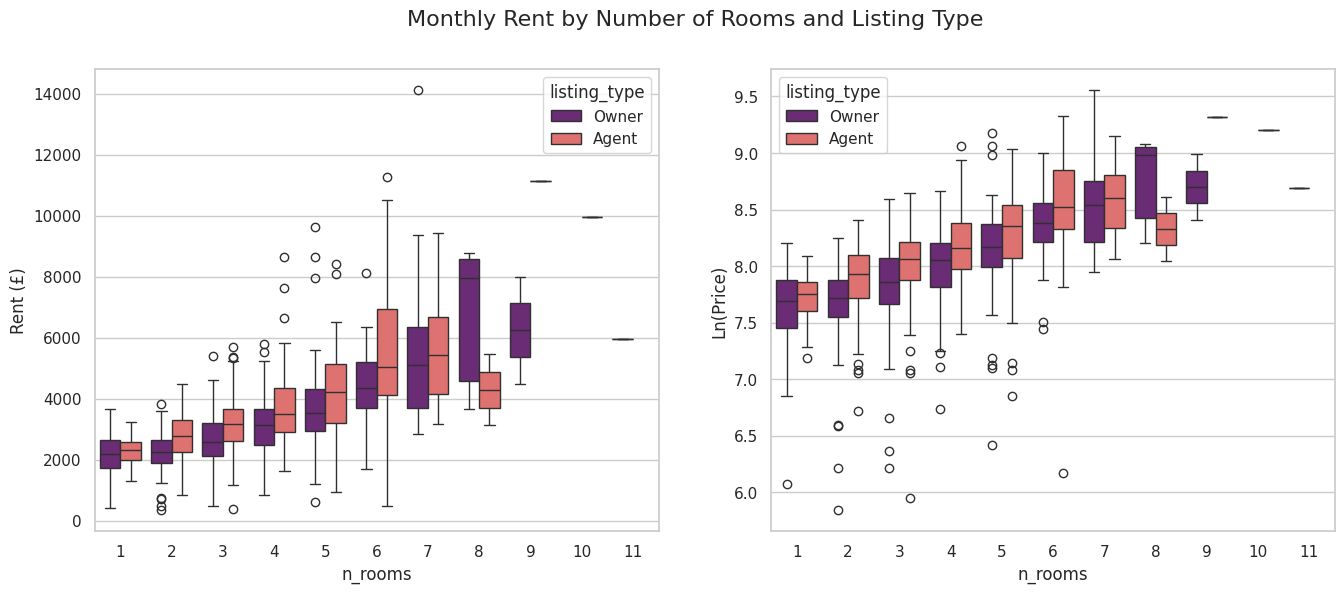

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Scale
sns.boxplot(
    data=df, x='n_rooms', y='monthly_rent_gbp', hue='listing_type', 
    palette='magma', hue_order=['Owner', 'Agent'], ax=axes[0]
)
axes[0].set_ylabel('Rent (£)')

# Ln Scale
sns.boxplot(
    data=df, x='n_rooms', y=np.log(df['monthly_rent_gbp']), hue='listing_type', 
    palette='magma', hue_order=['Owner', 'Agent'], ax=axes[1]
)
axes[1].set_ylabel('Ln(Price)')

plt.suptitle("Monthly Rent by Number of Rooms and Listing Type", fontsize=16)
plt.show()

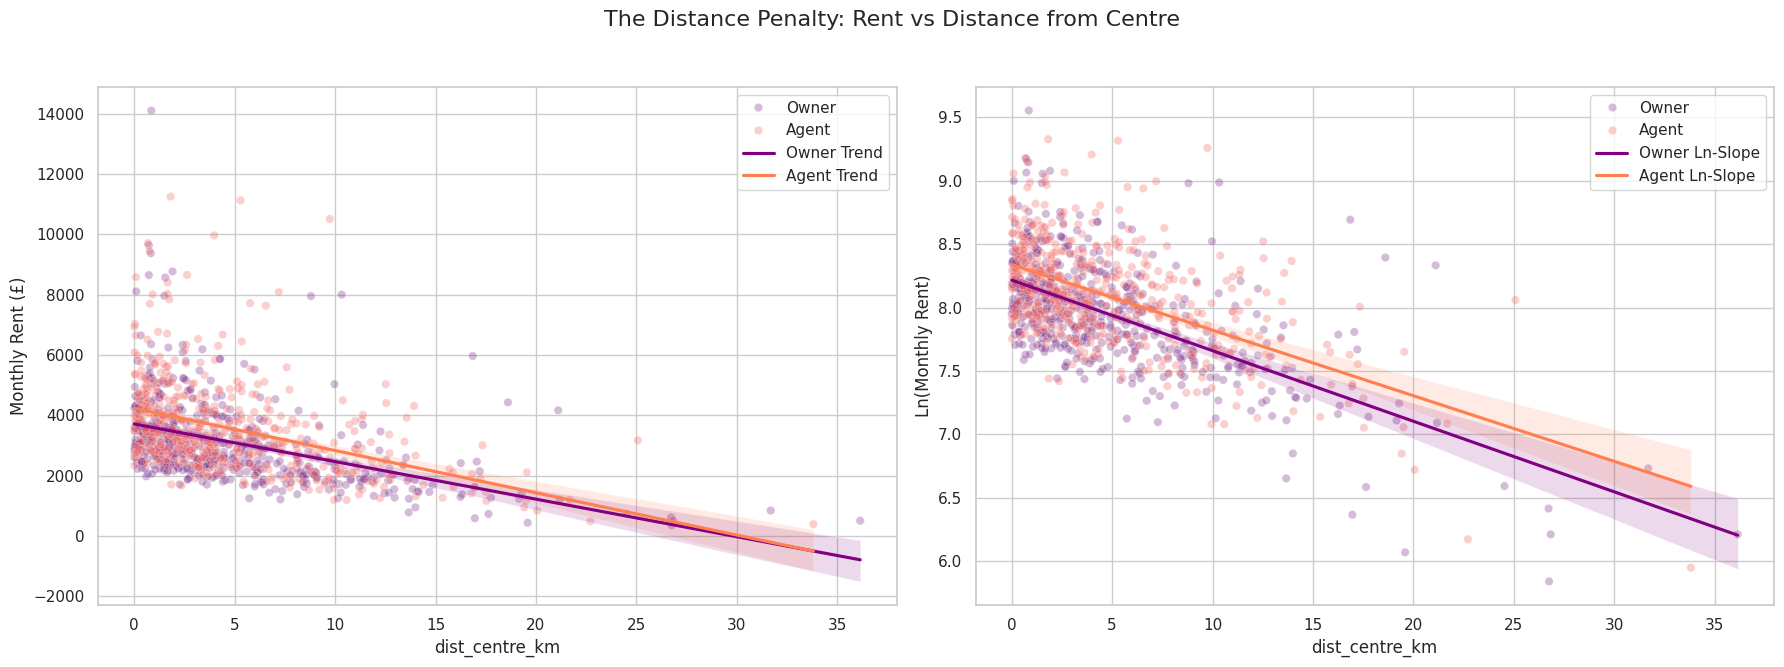

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Linear Scale ---
sns.scatterplot(data=df, x='dist_centre_km', y='monthly_rent_gbp', 
                hue='listing_type', hue_order=['Owner', 'Agent'],
                palette='magma', alpha=0.3, ax=axes[0])

# Separate dataframes for clean plotting
df_owner = df[df['listing_type']=='Owner']
df_agent = df[df['listing_type']=='Agent']

sns.regplot(data=df_owner, x='dist_centre_km', y='monthly_rent_gbp', 
            scatter=False, color='purple', label='Owner Trend', ax=axes[0])
sns.regplot(data=df_agent, x='dist_centre_km', y='monthly_rent_gbp', 
            scatter=False, color='coral', label='Agent Trend', ax=axes[0])

axes[0].set_ylabel('Monthly Rent (£)')
axes[0].legend()

# --- Ln Scale ---
# We calculate ln_rent as a temporary column to ensure indices match perfectly
df['ln_rent'] = np.log(df['monthly_rent_gbp'])

sns.scatterplot(data=df, x='dist_centre_km', y='ln_rent', 
                hue='listing_type', hue_order=['Owner', 'Agent'],
                palette='magma', alpha=0.3, ax=axes[1])

# Re-filter after adding the column
sns.regplot(data=df[df['listing_type']=='Owner'], x='dist_centre_km', y='ln_rent', 
            scatter=False, color='purple', label='Owner Ln-Slope', ax=axes[1])
sns.regplot(data=df[df['listing_type']=='Agent'], x='dist_centre_km', y='ln_rent', 
            scatter=False, color='coral', label='Agent Ln-Slope', ax=axes[1])

axes[1].set_ylabel('Ln(Monthly Rent)')
axes[1].legend()

plt.suptitle("The Distance Penalty: Rent vs Distance from Centre", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

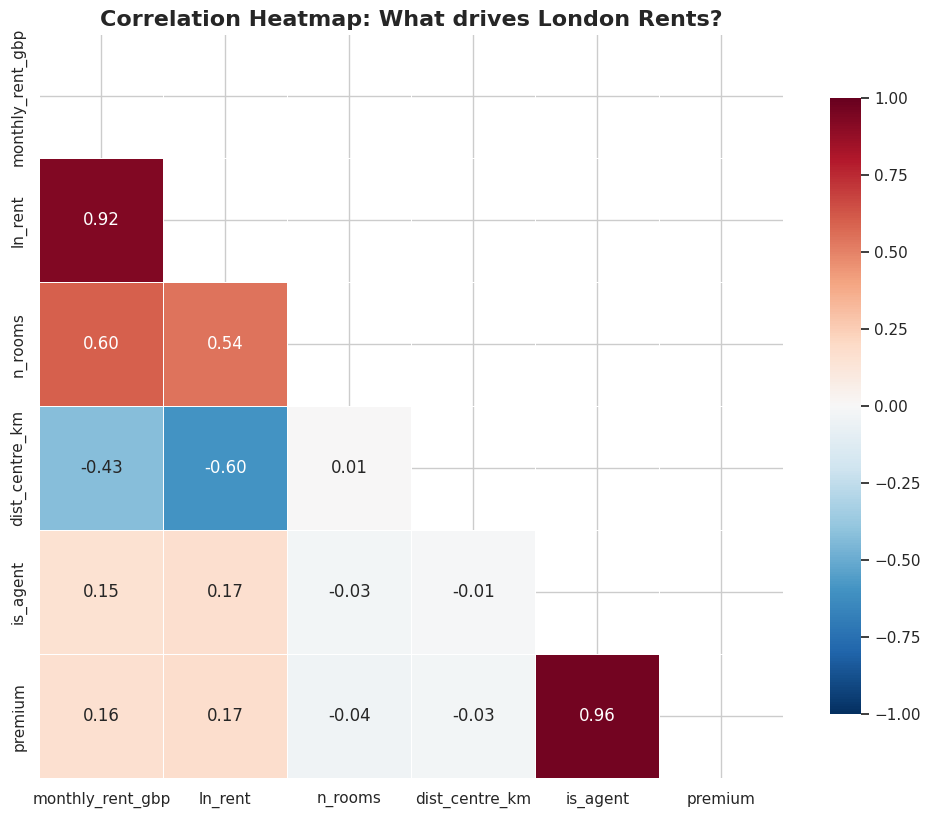

In [5]:
# --- HIERARCHICAL CORRELATION ANALYSIS ---

df_corr = df.copy()
df_corr['is_agent'] = (df['listing_type'] == 'Agent').astype(int)

target_cols = [
    'monthly_rent_gbp', 'ln_rent',             # Outcomes
    'n_rooms', 'dist_centre_km', 'is_agent',    # Observables
    'premium'
]

existing_cols = [c for c in target_cols if c in df_corr.columns]
correlation_matrix = df_corr[existing_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Mask the upper triangle for clarity

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='RdBu_r',
    fmt=".2f", 
    mask=mask, 
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap: What drives London Rents?', fontsize=16, fontweight='bold')
plt.show()

In [6]:
import configparser

def load_config(filename="../../app/config.ini"):
    """Parses the config.ini file into a usable dictionary."""
    # Use inline_comment_prefixes to ignore everything after '#'
    config_parser = configparser.ConfigParser(inline_comment_prefixes=('#',))
    config_parser.read(filename)

    c = {}

    # PRICE ARGUMENTS Section
    price = config_parser['PRICE_ARGUMENTS']
    c['agent_premium'] = float(price['agent_premium'])
    c['market_vol'] = float(price['market_vol'])
    c['premium_vol'] = float(price['agent_premium_vol_scale'])

    return c

config = load_config()

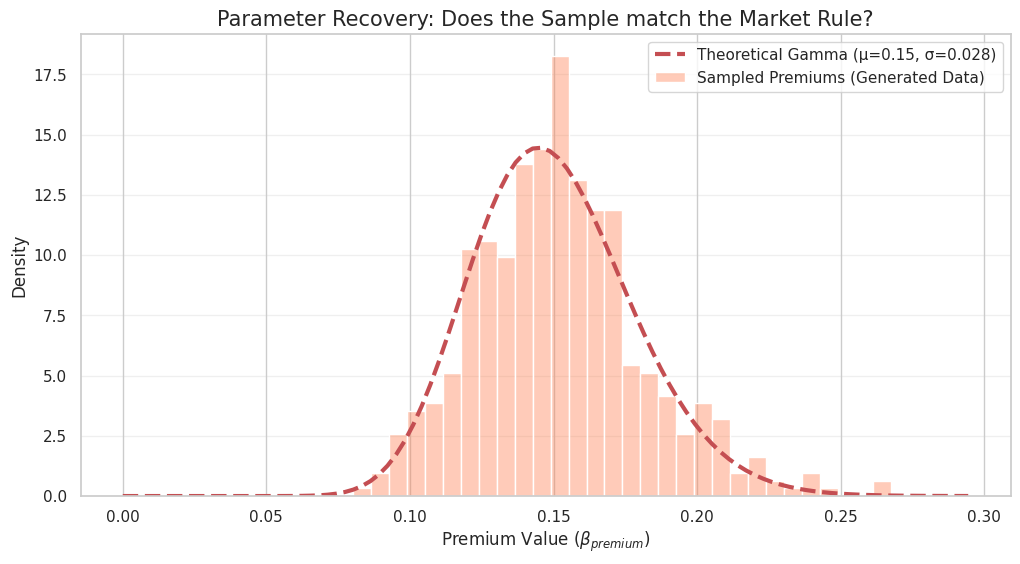

--- Numerical Audit ---
Target Mean: 0.1500 | Observed Mean: 0.1521
Target Std:  0.0280 | Observed Std:  0.0295


In [7]:
# --- PARAMETER RECOVERY (TRUTH CALIBRATION) ---

# Extract the generated premiums for Agents
agent_premiums = df[df['listing_type'] == 'Agent']['premium']

# Define the theoretical parameters used in generator
# alpha = (mean/sigma)**2 | beta = mean/(sigma**2)
m_mean = config['agent_premium'] 
m_sigma = config['market_vol'] * config['premium_vol']
shape_alpha = (m_mean / m_sigma)**2
scale_theta = (m_sigma**2) / m_mean

# Create the Plot
plt.figure(figsize=(12, 6))

# Plot the Actual Data (The "Sample")
sns.histplot(agent_premiums, bins=30, stat="density", color="coral", 
             alpha=0.4, label="Sampled Premiums (Generated Data)")

# Plot the Theoretical Curve (The "Market Rule")
x = np.linspace(0, agent_premiums.max() * 1.1, 100)
y = gamma.pdf(x, a=shape_alpha, scale=scale_theta)
plt.plot(x, y, 'r--', lw=3, label=f'Theoretical Gamma (μ={m_mean}, σ={m_sigma:.3f})')

# Formatting
plt.title("Parameter Recovery: Does the Sample match the Market Rule?", fontsize=15)
plt.xlabel("Premium Value ($\\beta_{premium}$)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Numerical Validation
print(f"--- Numerical Audit ---")
print(f"Target Mean: {m_mean:.4f} | Observed Mean: {agent_premiums.mean():.4f}")
print(f"Target Std:  {m_sigma:.4f} | Observed Std:  {agent_premiums.std():.4f}")

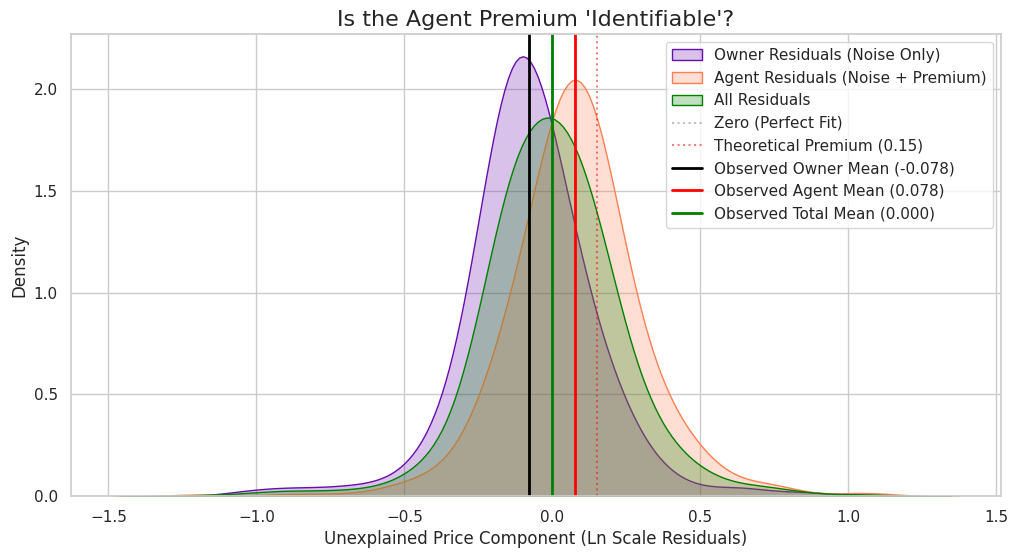

--- Recovered Physical Betas (OLS) ---
const               7.597847
n_rooms             0.152708
dist_centre_km     -0.053359
near_underground    0.085045
is_house            0.183680
has_garden          0.144966
has_terrace         0.097568
has_balcony         0.064656
dtype: float64

Distance between Observed Means: 0.1561


In [8]:
df["is_house"] = (df["property_type"] == "House").astype(int)
df["has_garden"] = (df["outdoor_space"] == "Garden").astype(int)
df["has_terrace"] = (df["outdoor_space"] == "Terrace").astype(int)
df["has_balcony"] = (df["outdoor_space"] == "Balcony").astype(int)

physical_features = [
    'n_rooms', 'dist_centre_km', 'near_underground',
    'is_house', 'has_garden', 'has_terrace', 'has_balcony'
]

# Fit OLS
X = sm.add_constant(df[physical_features].astype(float))
y = np.log(df['monthly_rent_gbp'])
clean_model = sm.OLS(y, X).fit()

# Extract Residuals
df['clean_residuals'] = y - clean_model.predict(X)

# Calculate Residual Means for plotting
owner_mean_res = df[df['listing_type']=='Owner']['clean_residuals'].mean()
agent_mean_res = df[df['listing_type']=='Agent']['clean_residuals'].mean()
mean_res = df['clean_residuals'].mean()

# Visualize
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['listing_type']=='Owner'], x='clean_residuals', 
            fill=True, color='#6A0DAD', label='Owner Residuals (Noise Only)', bw_adjust=1.5)
sns.kdeplot(data=df[df['listing_type']=='Agent'], x='clean_residuals', 
            fill=True, color='#FF7F50', label='Agent Residuals (Noise + Premium)', bw_adjust=1.5)
sns.kdeplot(data=df, x='clean_residuals', 
            fill=True, color='green', label='All Residuals', bw_adjust=1.5)

# Reference Lines
plt.axvline(0, color='grey', linestyle=':', alpha=0.5, label='Zero (Perfect Fit)')
plt.axvline(0.15, color='red', linestyle=':', alpha=0.5, label='Theoretical Premium (0.15)')

# Observed Mean Lines (Solid as requested)
plt.axvline(owner_mean_res, color='black', linestyle='-', linewidth=2, 
            label=f'Observed Owner Mean ({owner_mean_res:.3f})')
plt.axvline(agent_mean_res, color='red', linestyle='-', linewidth=2, 
            label=f'Observed Agent Mean ({agent_mean_res:.3f})')
plt.axvline(mean_res, color='green', linestyle='-', linewidth=2, 
            label=f'Observed Total Mean ({mean_res:.3f})')

plt.title("Is the Agent Premium 'Identifiable'?", fontsize=16)
plt.xlabel("Unexplained Price Component (Ln Scale Residuals)")
plt.ylabel("Density")
plt.legend()
plt.show()

# Diagnostics
print("--- Recovered Physical Betas (OLS) ---")
print(clean_model.params)
print(f"\nDistance between Observed Means: {agent_mean_res - owner_mean_res:.4f}")

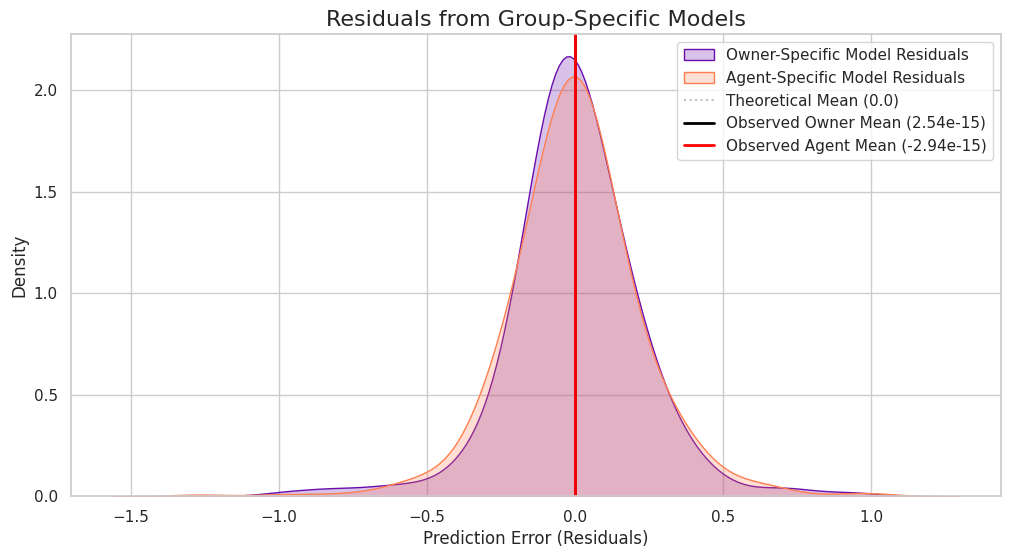

--- Beta Recovery Comparison ---
                  True Mean  Recovered (O)    SE (O)  Recovered (A)    SE (A)
const                  7.50       7.498204  0.030695       7.680490  0.029836
n_rooms                0.15       0.158097  0.006246       0.149882  0.006392
dist_centre_km        -0.05      -0.053859  0.001952      -0.051990  0.002193
near_underground       0.10       0.088158  0.021913       0.089073  0.022812
is_house               0.20       0.180438  0.023543       0.180695  0.023362
has_garden             0.15       0.140277  0.023485       0.164099  0.024679
has_terrace            0.10       0.114755  0.027977       0.073750  0.027005
has_balcony            0.05       0.093814  0.035365       0.043919  0.036857

Captured Agent Intercept Shift (Target ~0.15): 0.1823(±0.0839 at 95% CI)


In [9]:
physical_features = ['n_rooms', 'dist_centre_km', 'near_underground', 
                     'is_house', 'has_garden', 'has_terrace', 'has_balcony']

def get_ols_results(data_subset):
    X = sm.add_constant(data_subset[physical_features].astype(float))
    y = np.log(data_subset['monthly_rent_gbp'])
    model = sm.OLS(y, X).fit()
    residuals = y - model.predict(X)
    return model, residuals

# Perform OLS separately for each group
owner_model, owner_res = get_ols_results(df[df['listing_type'] == 'Owner'])
agent_model, agent_res = get_ols_results(df[df['listing_type'] == 'Agent'])

# Visualization
plt.figure(figsize=(12, 6))
sns.kdeplot(owner_res, fill=True, color='#6A0DAD', label='Owner-Specific Model Residuals', bw_adjust=1.5)
sns.kdeplot(agent_res, fill=True, color='#FF7F50', label='Agent-Specific Model Residuals', bw_adjust=1.5)

# Theoretical Means (Zero for both in this specific local-fit context)
plt.axvline(0, color='grey', linestyle=':', alpha=0.5, label='Theoretical Mean (0.0)')

# Observed Means (Calculated from residuals)
owner_obs_mean = owner_res.mean()
agent_obs_mean = agent_res.mean()

plt.axvline(owner_obs_mean, color='black', linestyle='-', linewidth=2, 
            label=f'Observed Owner Mean ({owner_obs_mean:.2e})')
plt.axvline(agent_obs_mean, color='red', linestyle='-', linewidth=2, 
            label=f'Observed Agent Mean ({agent_obs_mean:.2e})')

plt.title("Residuals from Group-Specific Models", fontsize=16)
plt.xlabel("Prediction Error (Residuals)")
plt.ylabel("Density")
plt.legend()
plt.show()

# Compare Recovered Betas
comparison_df = pd.DataFrame({
    'True Mean': [7.50, 0.15, -0.05, 0.10, 0.20, 0.15, 0.10, 0.05],
    'Recovered (O)': owner_model.params.values,
    'SE (O)': owner_model.bse,
    'Recovered (A)': agent_model.params.values,
    'SE (A)': agent_model.bse
}, index=['const'] + physical_features)

# Add the 'Premium' calculation for clarity
premium_recovery = agent_model.params['const'] - owner_model.params['const']
# Pooled error for the difference (Basic Propagation of Uncertainty)
combined_se = np.sqrt(owner_model.bse['const']**2 + agent_model.bse['const']**2)

print("--- Beta Recovery Comparison ---")
print(comparison_df)
print(f"\nCaptured Agent Intercept Shift (Target ~0.15): {premium_recovery:.4f}(±{1.96 * combined_se:.4f} at 95% CI)")

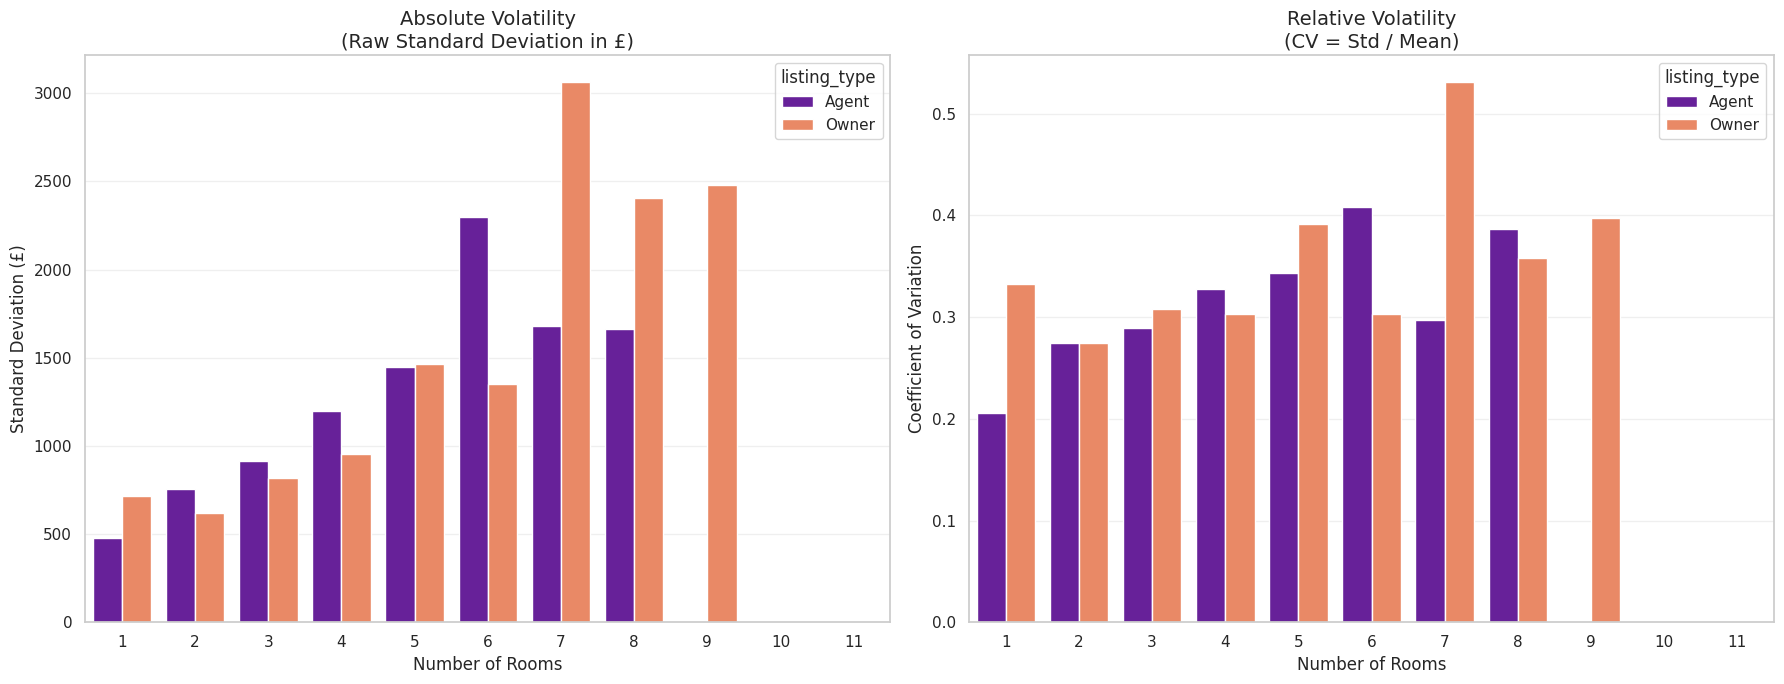

--- Market-Wide Volatility Summary ---
                     mean          std        cv
listing_type                                    
Agent         3556.769473  1544.384813  0.434210
Owner         3091.667425  1425.965329  0.461229

Result:
1. Agents have 8.3% more absolute noise (£) than Owners.
2. Agents have -5.9% more relative noise (%) than Owners.


In [10]:
# Calculate Grouped Stats
stats = df.groupby(['n_rooms', 'listing_type'])['monthly_rent_gbp'].agg(['mean', 'std']).reset_index()
stats['cv'] = stats['std'] / stats['mean']

# Setup Figure for Side-by-Side Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: Absolute Standard Deviation
sns.barplot(data=stats, x='n_rooms', y='std', hue='listing_type', 
            palette=['#6A0DAD', '#FF7F50'], ax=ax1)
ax1.set_title("Absolute Volatility\n(Raw Standard Deviation in £)", fontsize=14)
ax1.set_ylabel("Standard Deviation (£)")
ax1.set_xlabel("Number of Rooms")
ax1.grid(axis='y', alpha=0.3)

# Plot B: Relative Volatility (CV)
sns.barplot(data=stats, x='n_rooms', y='cv', hue='listing_type', 
            palette=['#6A0DAD', '#FF7F50'], ax=ax2)
ax2.set_title("Relative Volatility\n(CV = Std / Mean)", fontsize=14)
ax2.set_ylabel("Coefficient of Variation")
ax2.set_xlabel("Number of Rooms")
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print Global Summaries
global_stats = df.groupby('listing_type')['monthly_rent_gbp'].agg(['mean', 'std'])
global_stats['cv'] = global_stats['std'] / global_stats['mean']

print("--- Market-Wide Volatility Summary ---")
print(global_stats)

# Insight calculations
std_diff = ((global_stats.loc['Agent', 'std'] / global_stats.loc['Owner', 'std']) - 1) * 100
cv_diff = ((global_stats.loc['Agent', 'cv'] / global_stats.loc['Owner', 'cv']) - 1) * 100

print(f"\nResult:")
print(f"1. Agents have {std_diff:.1f}% more absolute noise (£) than Owners.")
print(f"2. Agents have {cv_diff:.1f}% more relative noise (%) than Owners.")